In [ ]:
%run scripts/verify_environment.py

verify_environment()

In [ ]:
from datetime import datetime
from getpass import getpass

rdm_url = 'https://bh.rdm.yzwlab.com/' # 'https://staging.rdm.example.com'
idp_name_project_limit_1 = None
idp_username_project_limit_1 = None
idp_password_project_limit_1 = None
idp_name_project_limit_2 = None
idp_username_project_limit_2 = None
idp_password_project_limit_2 = None
rdm_project_name = 'TEST-ユーザ権限設定機能検証操作-{}'.format(datetime.now().strftime('%Y%m%d-%H%M%S'))
default_result_path = None
close_on_fail = False
transition_timeout = 30000

In [3]:
if idp_name_project_limit_1 is None:
    idp_name_project_limit_1 = input(prompt=f'IdP Name: ')
if idp_username_project_limit_1 is None:
    idp_username_project_limit_1 = input(prompt=f'Username for {idp_name_project_limit_1}')
if idp_password_project_limit_1 is None:
    idp_password_project_limit_1 = getpass(prompt=f'Password for {idp_username_project_limit_1}@{idp_name_project_limit_1}')

if idp_name_project_limit_2 is None:
    idp_name_project_limit_2 = input(prompt=f'IdP Name: ')
if idp_username_project_limit_2 is None:
    idp_username_project_limit_2 = input(prompt=f'Username for {idp_name_project_limit_2}')
if idp_password_project_limit_2 is None:
    idp_password_project_limit_2 = getpass(prompt=f'Password for {idp_username_project_limit_2}@{idp_name_project_limit_2}')

In [ ]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

# NIIストレージ_プロジェクト作成(切り戻し②)

- サブシステム名: NIIストレージ (プロジェクト作成)
- ページ/アドオン: NIIストレージ
- 機能分類: プロジェクト作成
- シナリオ名: NIIストレージ(デフォルトストレージ)に対するプロジェクト作成
- 用意するテストデータ: URL一覧、アカウント(既存ユーザー1: GRDM, 既存ユーザー2: GRDM)

In [ ]:
import importlib

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *
from scripts import grdm

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

## ウェブブラウザの新規プライベートウィンドウでGRDMトップページを表示する

GRDMトップページが表示されること


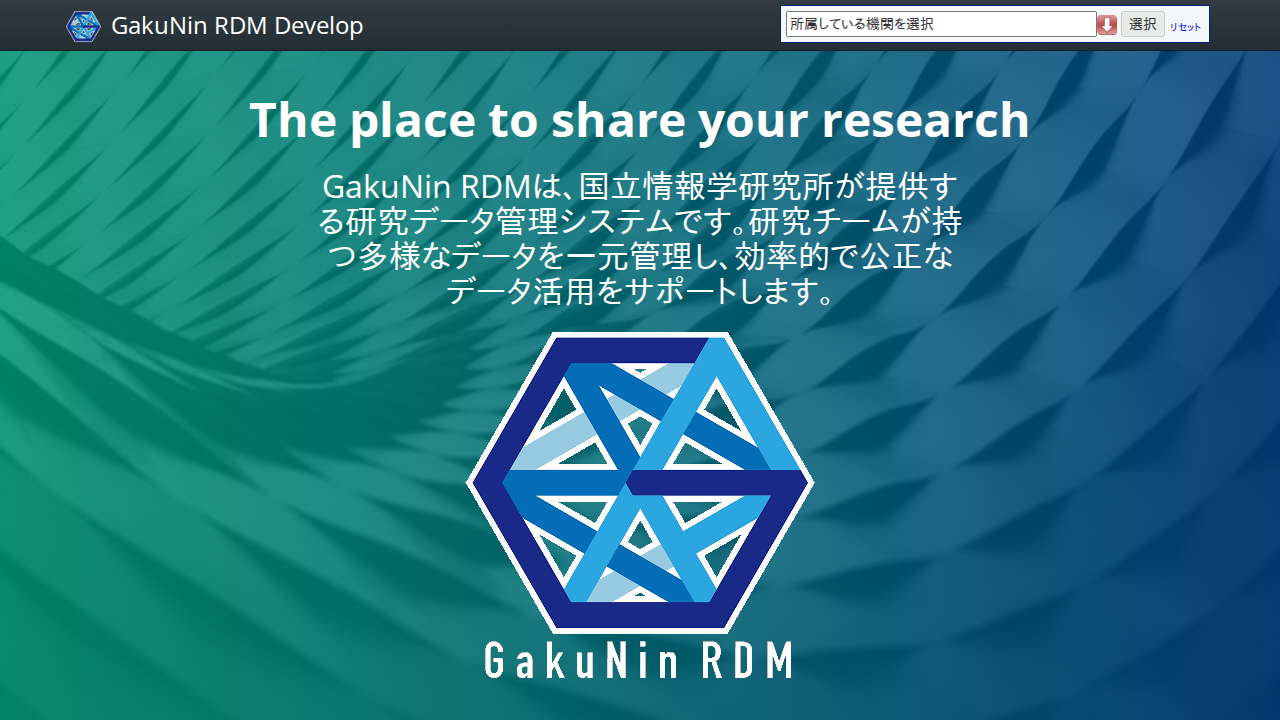

In [6]:
async def _step(page):
    await page.goto(rdm_url)

    # 同意する ボタンが現れるまで待つ
    await expect(page.locator('//button[text() = "同意する"]')).to_be_visible(timeout=transition_timeout)

    # 同意する をクリック
    await page.locator('//button[text() = "同意する"]').click()

    # 同意する が表示されなくなったことを確認
    await expect(page.locator('//button[text() = "同意する"]')).to_have_count(0, timeout=transition_timeout)

await run_pw(_step)

## RDMIdPを利用し、既存ユーザー1としてログインする

GRDMダッシュボードが表示されること


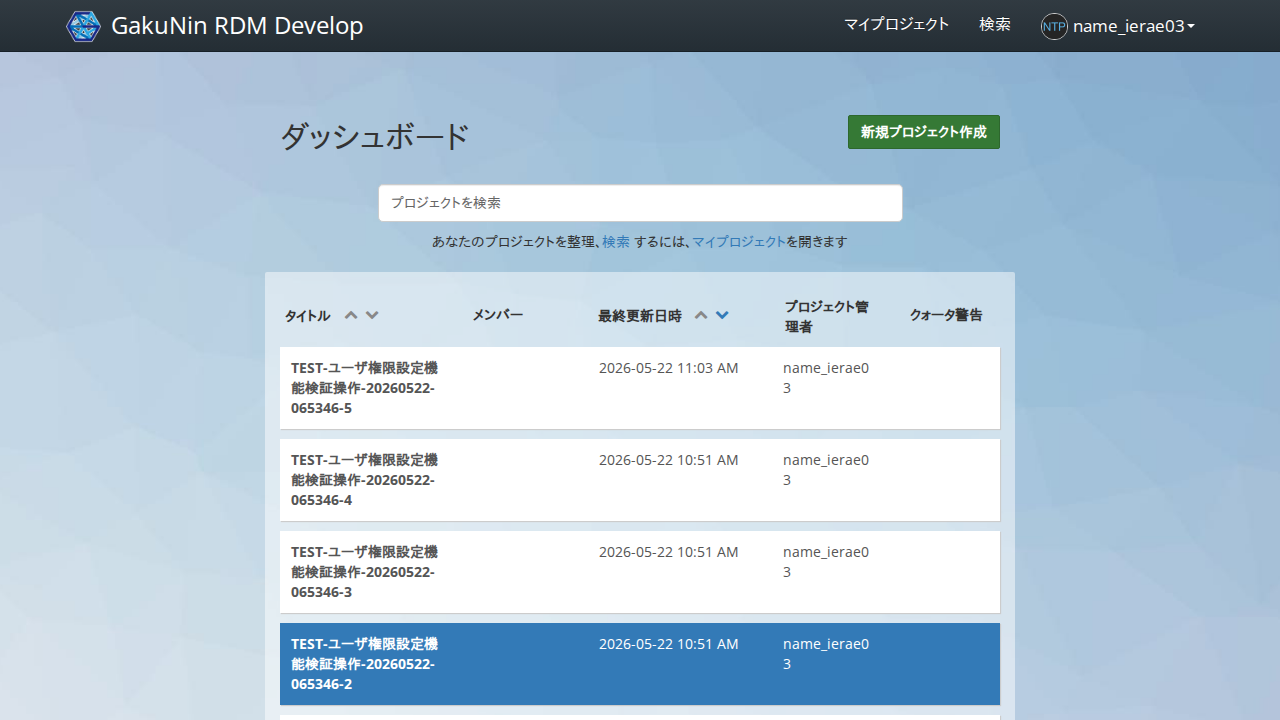

In [7]:
async def _step(page):
    await scripts.grdm.login(
        page, idp_name_project_limit_1, idp_username_project_limit_1, idp_password_project_limit_1, transition_timeout=transition_timeout
    )

    await scripts.grdm.expect_dashboard(page, transition_timeout=transition_timeout)

await run_pw(_step)

## タイトル「TEST-ユーザ権限設定機能検証操作-YYYYMMDD(本日の日付)-6」でプロジェクトを作成する

・ダッシュボードのプロジェクト一覧に入力したプロジェクト名のプロジェクトが追加されること   
・ダッシュボードの「新規プロジェクト作成」ボタンが有効になること   


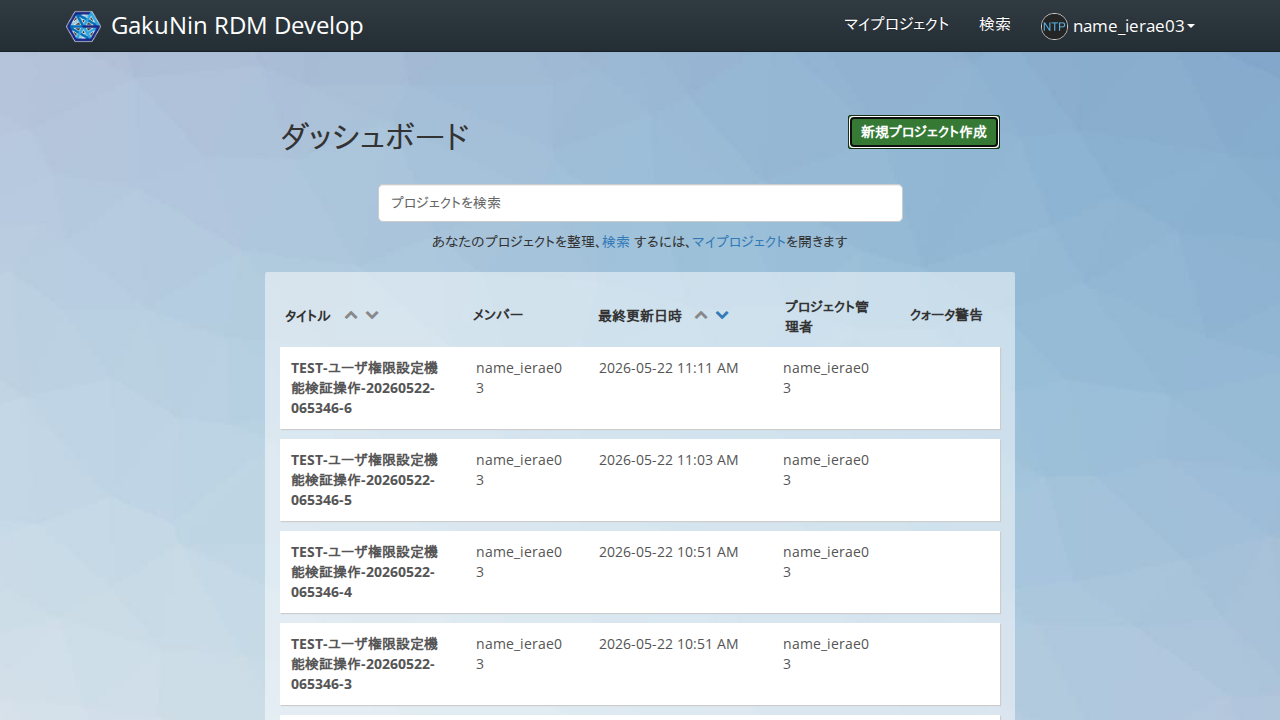

In [8]:
async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1, timeout=transition_timeout)

    await scripts.grdm.ensure_project_exists(page, rdm_project_name + '-6', transition_timeout=transition_timeout)
    
    await expect(page.locator('button:has-text("新規プロジェクト作成")')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## タイトル「TEST-ユーザ権限設定機能検証操作-YYYYMMDD(本日の日付)-7」でプロジェクトを作成する

・ダッシュボードのプロジェクト一覧に入力したプロジェクト名のプロジェクトが追加されること   
・ダッシュボードの「新規プロジェクト作成」ボタンが有効になること   


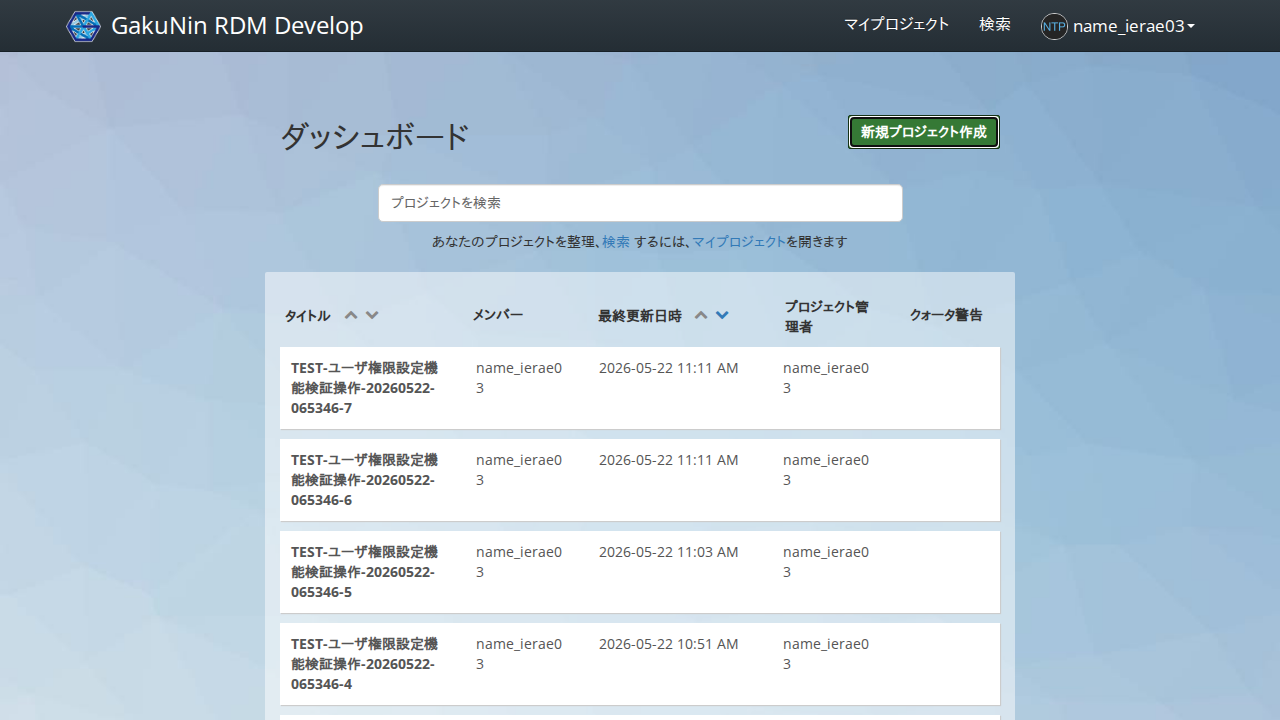

In [9]:
async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1, timeout=transition_timeout)

    await scripts.grdm.ensure_project_exists(page, rdm_project_name + '-7', transition_timeout=transition_timeout)
    
    await expect(page.locator('button:has-text("新規プロジェクト作成")')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## タイトル「TEST-ユーザ権限設定機能検証操作-YYYYMMDD(本日の日付)-8」でプロジェクトを作成する

・ダッシュボードのプロジェクト一覧に入力したプロジェクト名のプロジェクトが追加されること   
・ダッシュボードの「新規プロジェクト作成」ボタンが有効になること   


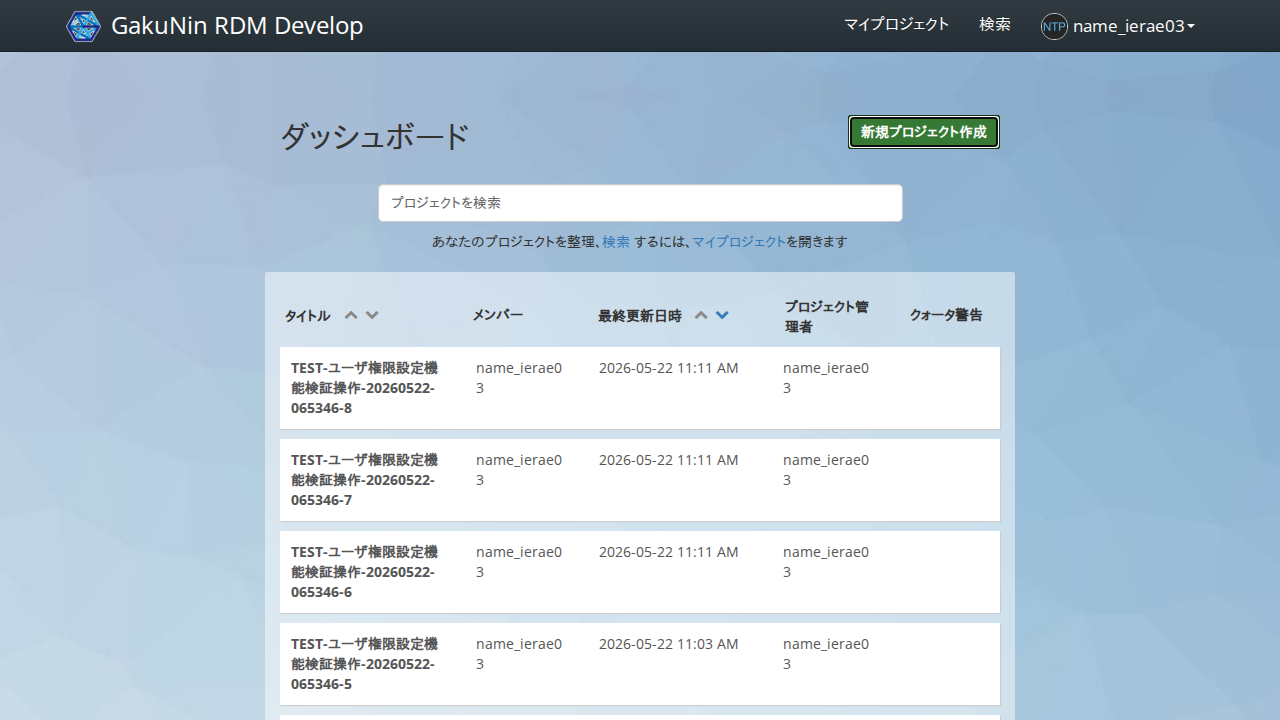

In [10]:
async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1, timeout=transition_timeout)

    await scripts.grdm.ensure_project_exists(page, rdm_project_name + '-8', transition_timeout=transition_timeout)
    
    await expect(page.locator('button:has-text("新規プロジェクト作成")')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## タイトル「TEST-ユーザ権限設定機能検証操作-YYYYMMDD(本日の日付)-9」でプロジェクトを作成する

・ダッシュボードのプロジェクト一覧に入力したプロジェクト名のプロジェクトが追加されること   
・ダッシュボードの「新規プロジェクト作成」ボタンが有効になること   


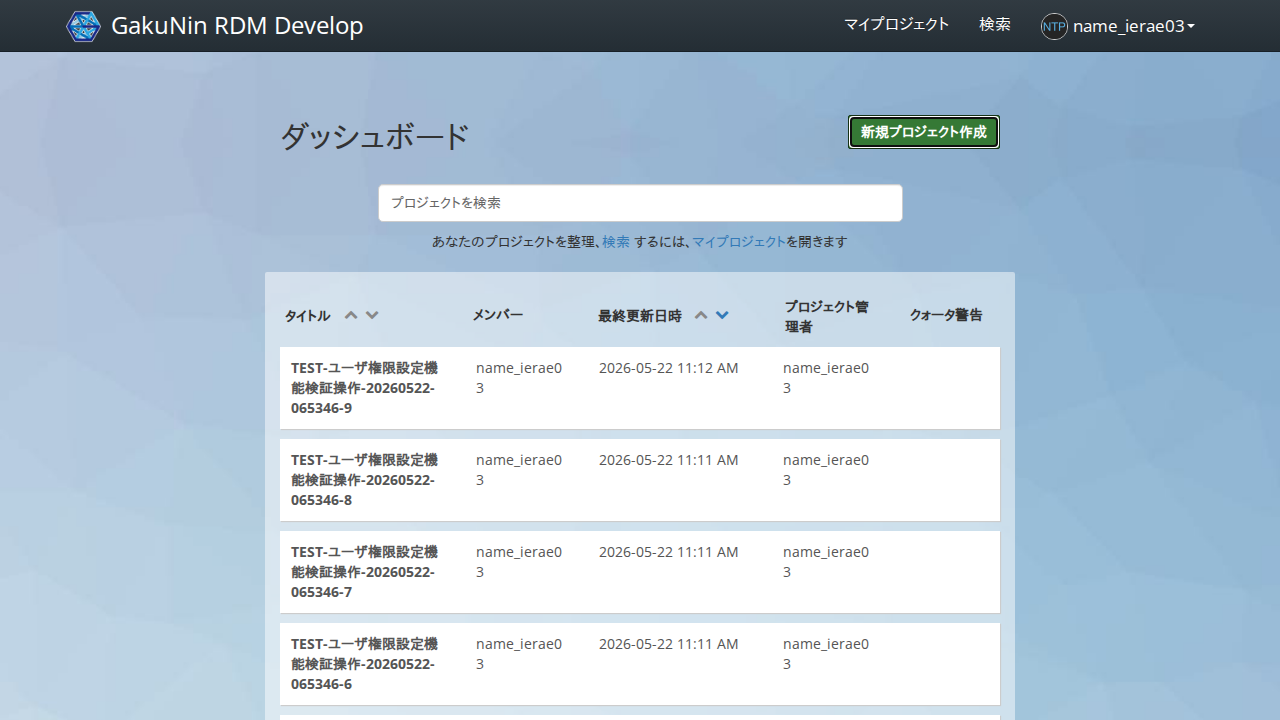

In [11]:
async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1, timeout=transition_timeout)

    await scripts.grdm.ensure_project_exists(page, rdm_project_name + '-9', transition_timeout=transition_timeout)
    
    await expect(page.locator('button:has-text("新規プロジェクト作成")')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## タイトル「TEST-ユーザ権限設定機能検証操作-YYYYMMDD(本日の日付)-10」でプロジェクトを作成する

・ダッシュボードのプロジェクト一覧に入力したプロジェクト名のプロジェクトが追加されること   
・ダッシュボードの「新規プロジェクト作成」ボタンが有効になること   


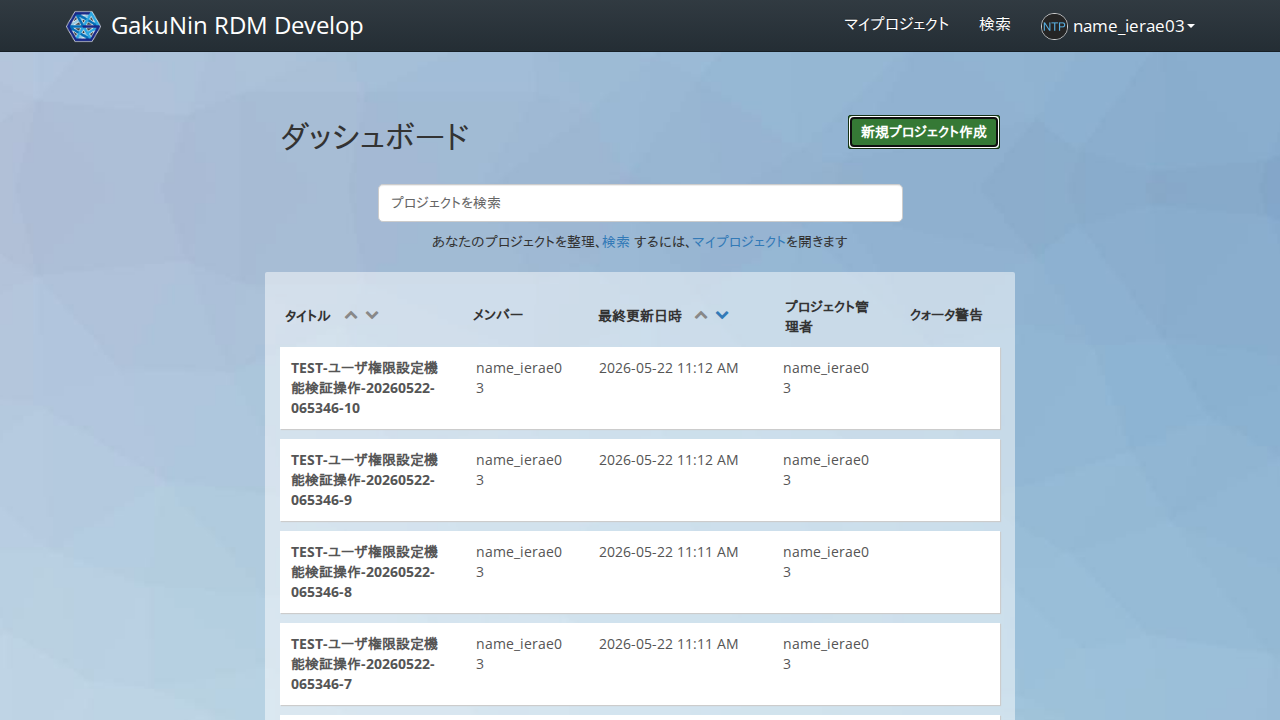

In [12]:
async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1, timeout=transition_timeout)

    await scripts.grdm.ensure_project_exists(page, rdm_project_name + '-10', transition_timeout=transition_timeout)
    
    await expect(page.locator('button:has-text("新規プロジェクト作成")')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## ダッシュボード画面をリロードする

・ダッシュボードの「新規プロジェクト作成」ボタンが有効のままになっていること


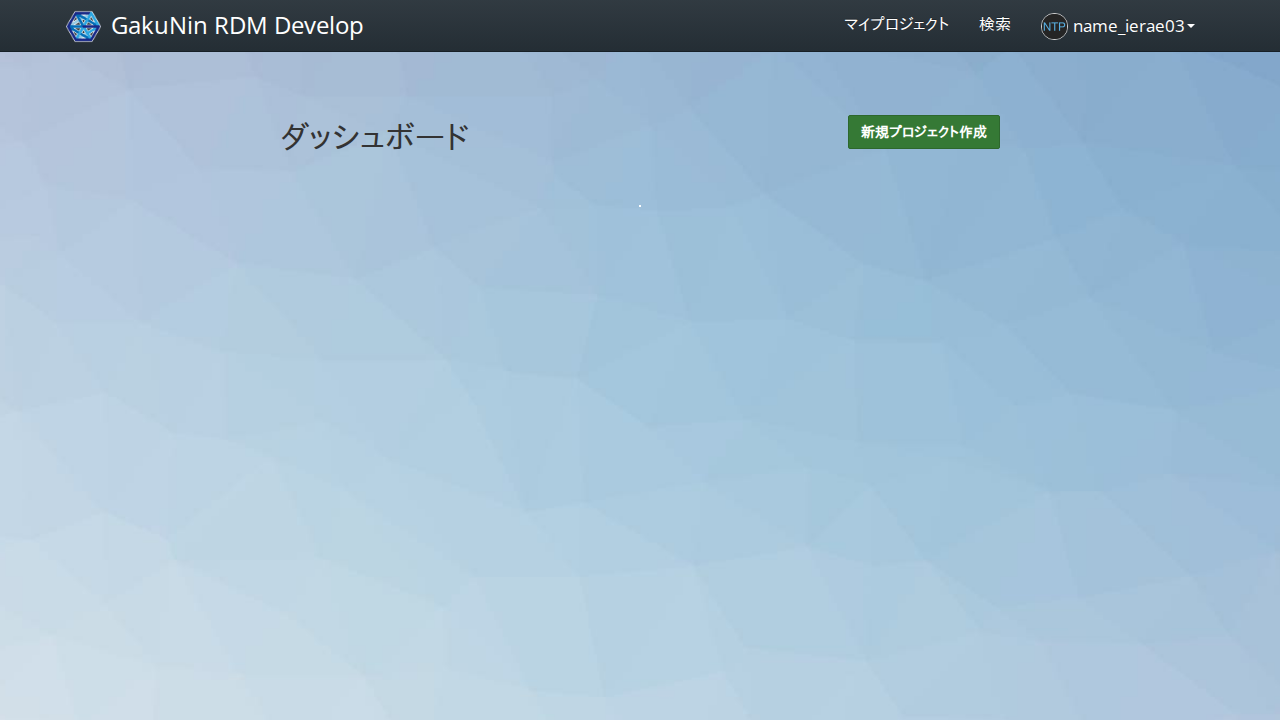

In [13]:
async def _step(page):
    await page.reload()

    await expect(page.locator('button:has-text("新規プロジェクト作成")')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## 既存ユーザー1をログアウトする

ログアウトが完了すること

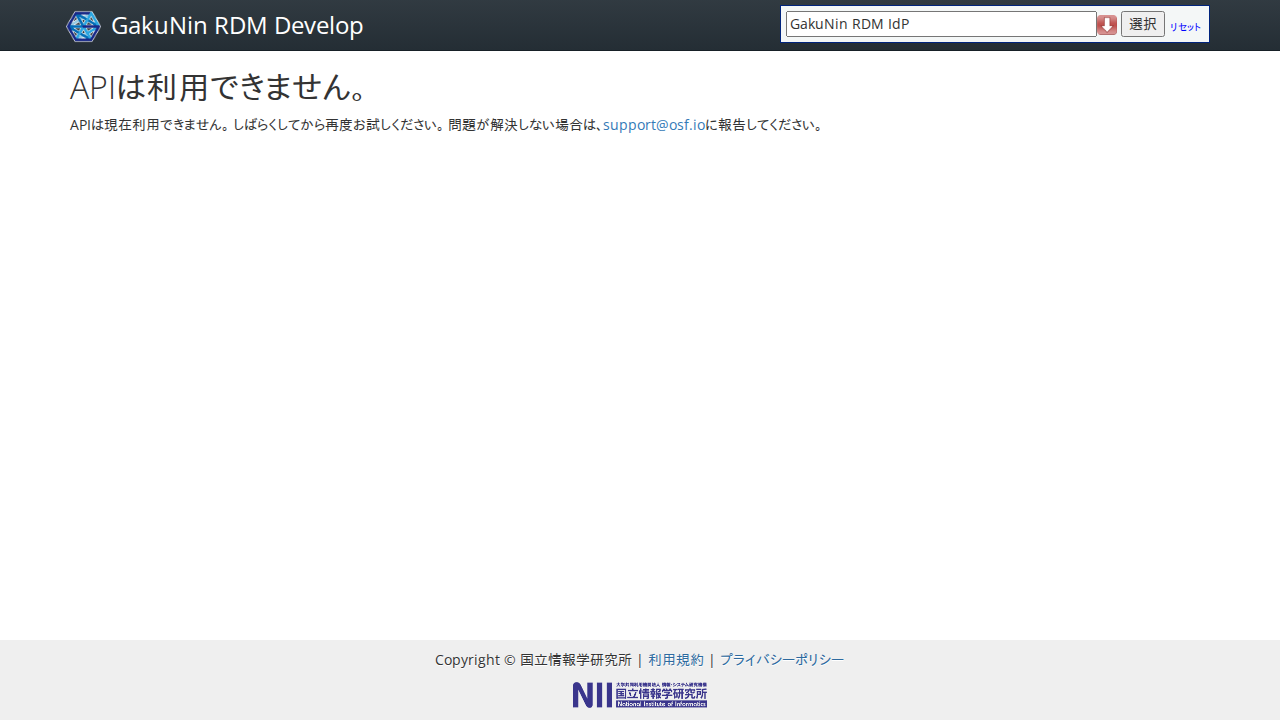

In [14]:
async def _step(page):
    await grdm.logout(page, idp_name_project_limit_1, transition_timeout=transition_timeout)

await run_pw(_step)

## RDMIdPを利用し、既存ユーザー2としてログインする

・GRDMダッシュボードが表示されること
・ダッシュボードの「新規プロジェクト作成」ボタンが有効になっていること


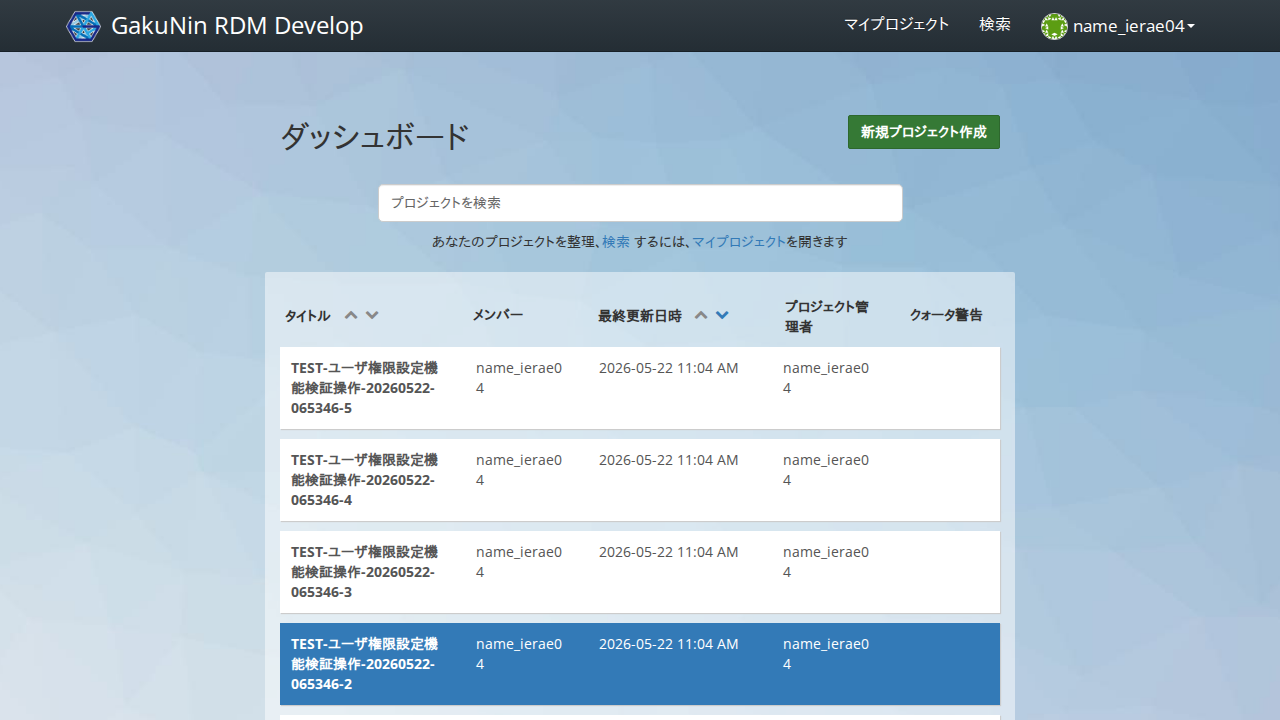

In [ ]:
async def _step(page):
    if idp_name_project_limit_2 != 'FakeCAS':
        # ログアウト後、トップページは機関が選択済みの状態で表示される。
        # ログインを実施できるようにするため、トップページを未選択状態へ戻す目的でリセットボタンおよび dropdown_up ボタンをクリックする。
        await page.locator('//*[@id = "clear_a"]').click()
        await page.locator('//*[@id = "dropdown_img"]').click()
        await expect(page.locator('img[src*="dropdown_down.png"]')).to_be_visible(timeout=transition_timeout)

    await scripts.grdm.login(
        page, idp_name_project_limit_2, idp_username_project_limit_2, idp_password_project_limit_2, transition_timeout=transition_timeout
    )

    await scripts.grdm.expect_dashboard(page, transition_timeout=transition_timeout)
    
    await expect(page.locator('button:has-text("新規プロジェクト作成")')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## タイトル「TEST-ユーザ権限設定機能検証操作-YYYYMMDD(本日の日付)-6」でプロジェクトを作成する

・ダッシュボードのプロジェクト一覧に入力したプロジェクト名のプロジェクトが追加されること   
・ダッシュボードの「新規プロジェクト作成」ボタンが有効になること   


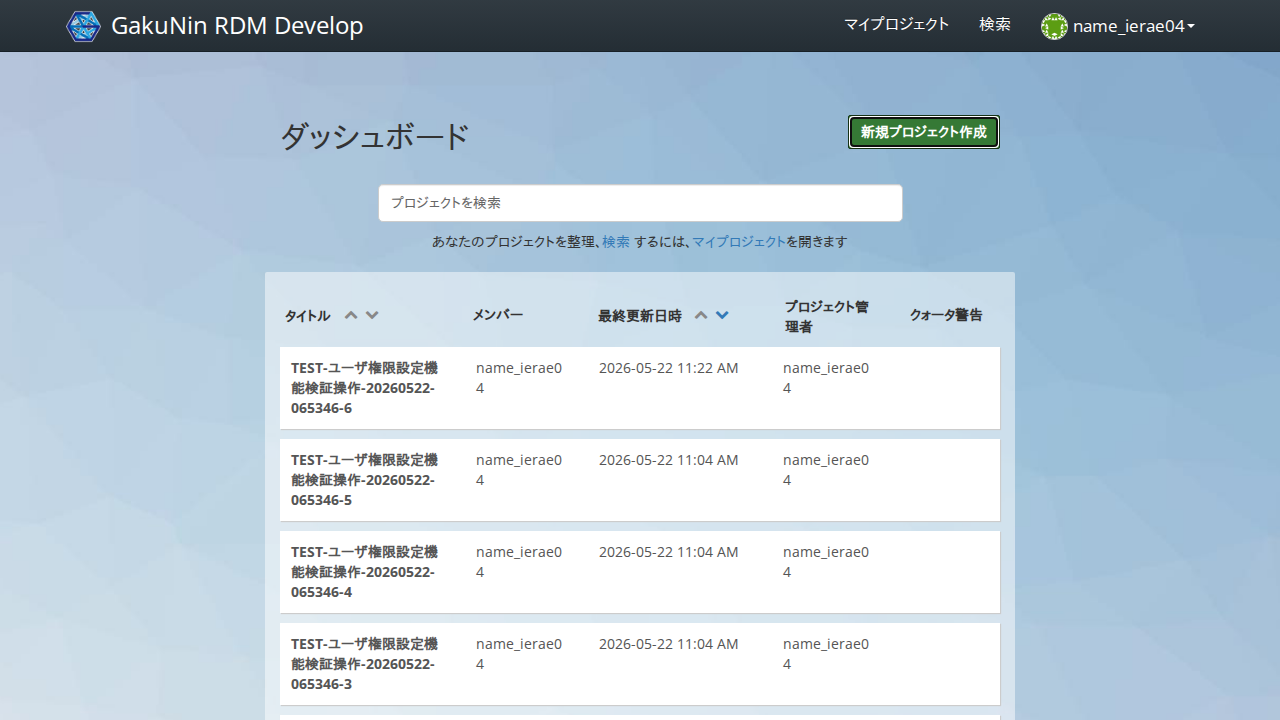

In [18]:
async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1, timeout=transition_timeout)

    await scripts.grdm.ensure_project_exists(page, rdm_project_name + '-6', transition_timeout=transition_timeout)
    
    await expect(page.locator('button:has-text("新規プロジェクト作成")')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## タイトル「TEST-ユーザ権限設定機能検証操作-YYYYMMDD(本日の日付)-7」でプロジェクトを作成する

・ダッシュボードのプロジェクト一覧に入力したプロジェクト名のプロジェクトが追加されること   
・ダッシュボードの「新規プロジェクト作成」ボタンが有効になること   


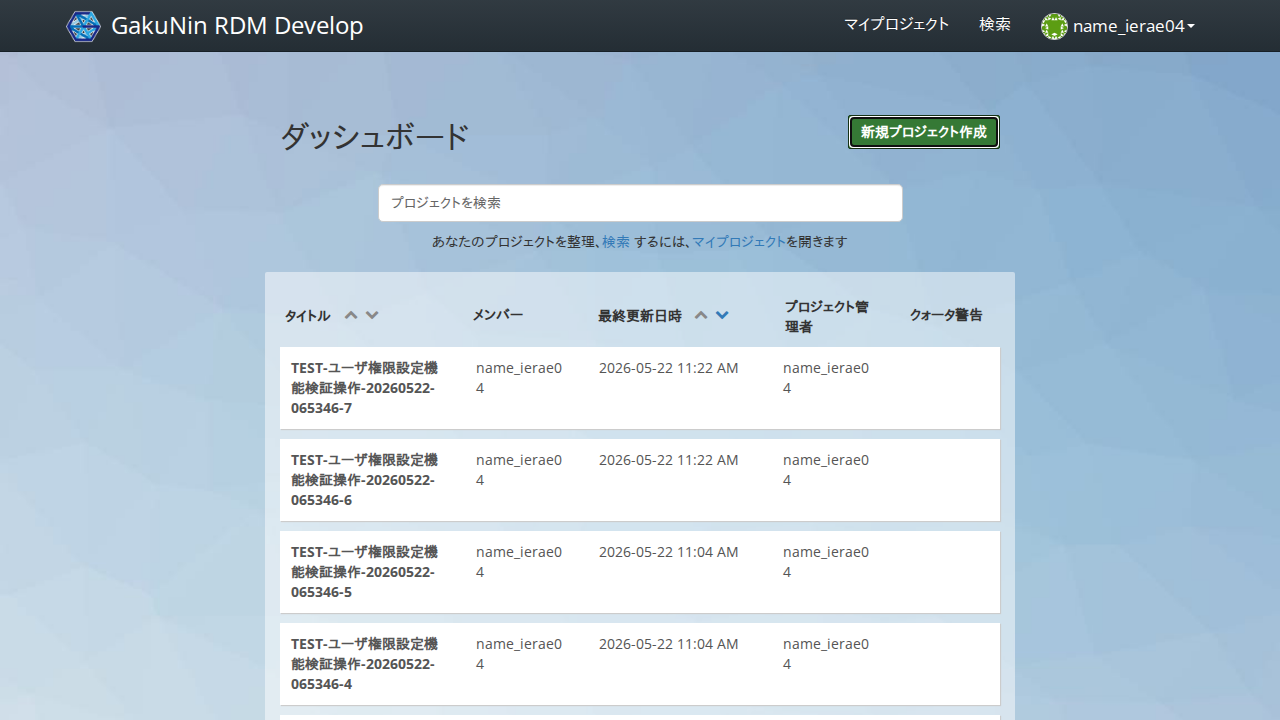

In [19]:
async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1, timeout=transition_timeout)

    await scripts.grdm.ensure_project_exists(page, rdm_project_name + '-7', transition_timeout=transition_timeout)
    
    await expect(page.locator('button:has-text("新規プロジェクト作成")')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## タイトル「TEST-ユーザ権限設定機能検証操作-YYYYMMDD(本日の日付)-8」でプロジェクトを作成する

・ダッシュボードのプロジェクト一覧に入力したプロジェクト名のプロジェクトが追加されること  
・ダッシュボードの「新規プロジェクト作成」ボタンが有効になること   


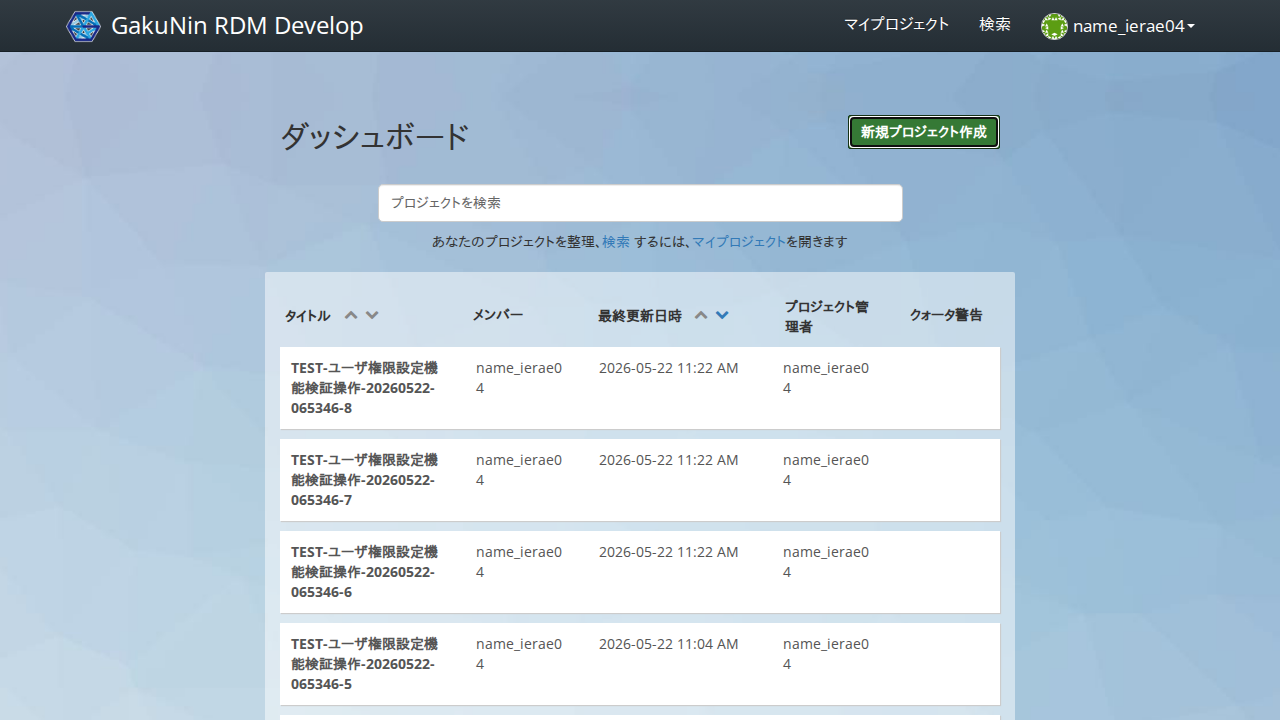

In [20]:
async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1, timeout=transition_timeout)

    await scripts.grdm.ensure_project_exists(page, rdm_project_name + '-8', transition_timeout=transition_timeout)
    
    await expect(page.locator('button:has-text("新規プロジェクト作成")')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## タイトル「TEST-ユーザ権限設定機能検証操作-YYYYMMDD(本日の日付)-9」でプロジェクトを作成する

・ダッシュボードのプロジェクト一覧に入力したプロジェクト名のプロジェクトが追加されること   
・ダッシュボードの「新規プロジェクト作成」ボタンが有効になること   


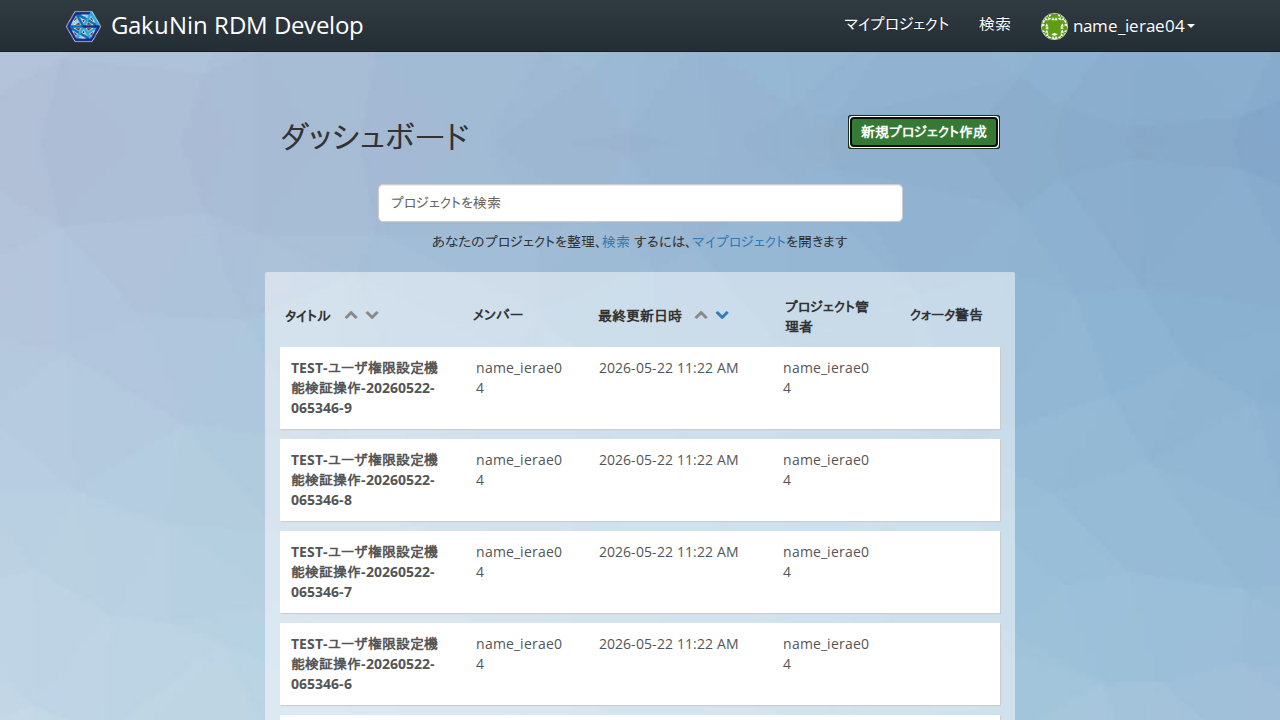

In [21]:
async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1, timeout=transition_timeout)

    await scripts.grdm.ensure_project_exists(page, rdm_project_name + '-9', transition_timeout=transition_timeout)
    
    await expect(page.locator('button:has-text("新規プロジェクト作成")')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## タイトル「TEST-ユーザ権限設定機能検証操作-YYYYMMDD(本日の日付)-10」でプロジェクトを作成する

・ダッシュボードのプロジェクト一覧に入力したプロジェクト名のプロジェクトが追加されること   
・ダッシュボードの「新規プロジェクト作成」ボタンが有効になること   

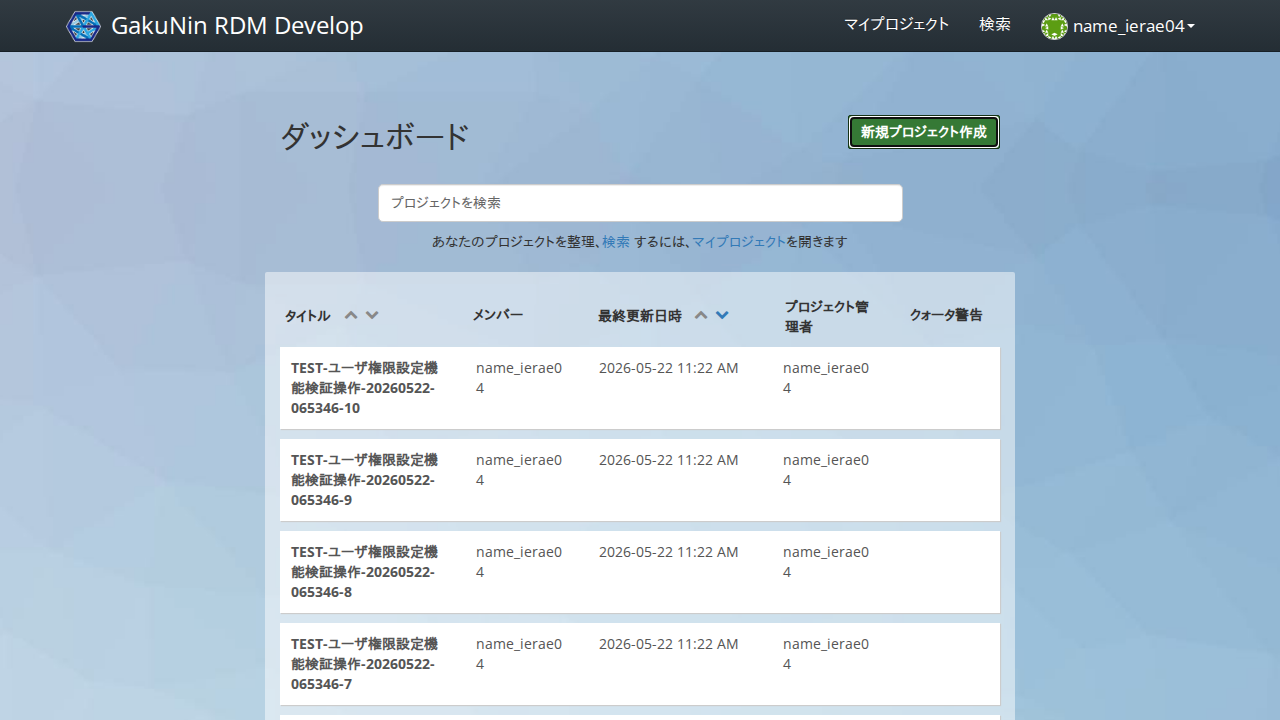

In [22]:
async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1, timeout=transition_timeout)

    await scripts.grdm.ensure_project_exists(page, rdm_project_name + '-10', transition_timeout=transition_timeout)
    
    await expect(page.locator('button:has-text("新規プロジェクト作成")')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## ダッシュボード画面をリロードする

・ダッシュボードの「新規プロジェクト作成」ボタンが有効のままになっていること


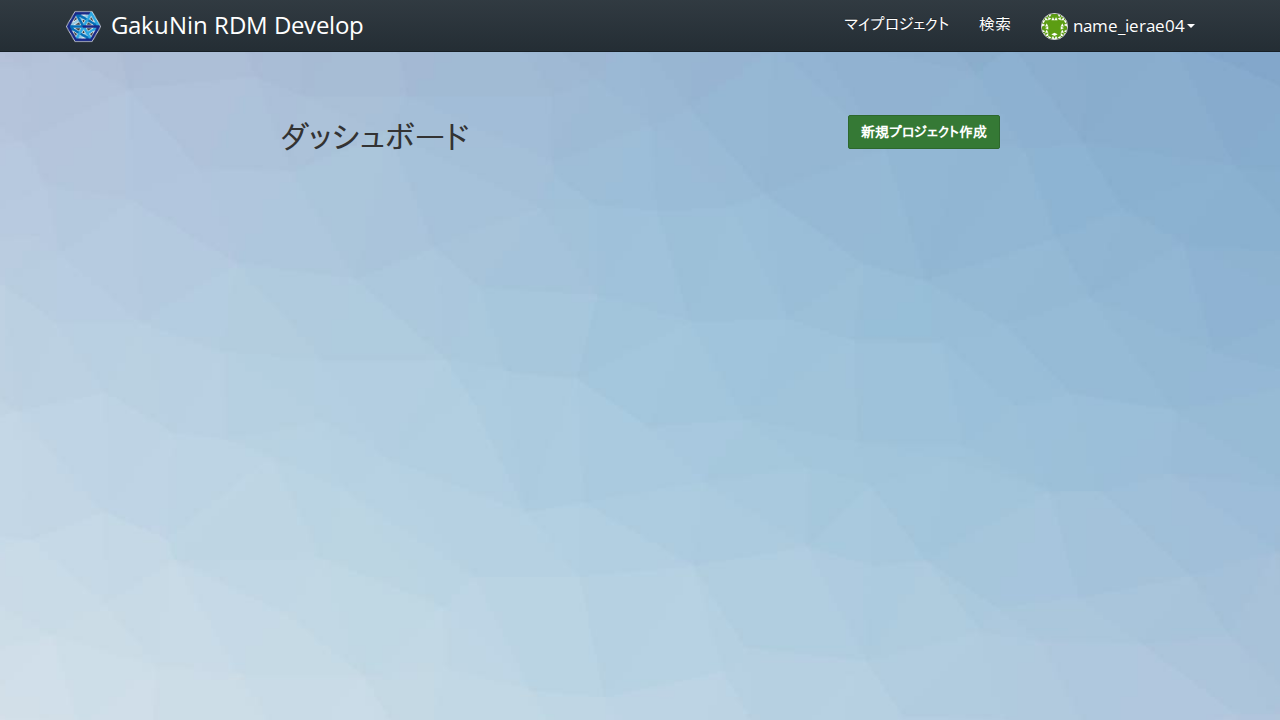

In [23]:
async def _step(page):
    await page.reload()

    await expect(page.locator('button:has-text("新規プロジェクト作成")')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

終了処理を実施。

In [ ]:
await finish_pw_context()

In [ ]:
!rm -fr {work_dir}